# 第 7 章 · 感知机与梯度下降

房价 MSE 逐轮下降、感知机边界 b 更新、分类阈值与 P/R。

配套交互演示：[章节网页](../ch7.html)

## 本节目标

- 梯度下降逐步 trace
- 感知机决策边界
- 阈值与 P/R 权衡

## 1. 梯度下降

最小化 MSE：沿负梯度方向更新权重 w，学习率控制步长。

**GD**

```text
w <- w - lr * d(MSE)/dw
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch07"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from learning import *
from common.codelens import print_frames as print_codelens

In [2]:
gd_frames = codelens_gd()

In [3]:
print_codelens(gd_frames)

── Step 0 ── 初始权重
   执行: w=0
   w = 0.0
   MSE = 8420

── Step 1 ── 第 1 轮梯度下降
   执行: w -= lr*grad  # iter 1
   w = 0.15
   MSE = 5200

── Step 2 ── 第 2 轮梯度下降
   执行: w -= lr*grad  # iter 2
   w = 0.3
   MSE = 3100

── Step 3 ── 第 3 轮梯度下降
   执行: w -= lr*grad  # iter 3
   w = 0.45
   MSE = 1800

── Step 4 ── 第 4 轮梯度下降
   执行: w -= lr*grad  # iter 4
   w = 0.6
   MSE = 920



In [4]:
gd_demo()

MSE 下降: 8420 → 5200 → 3100 → 1800 → 920


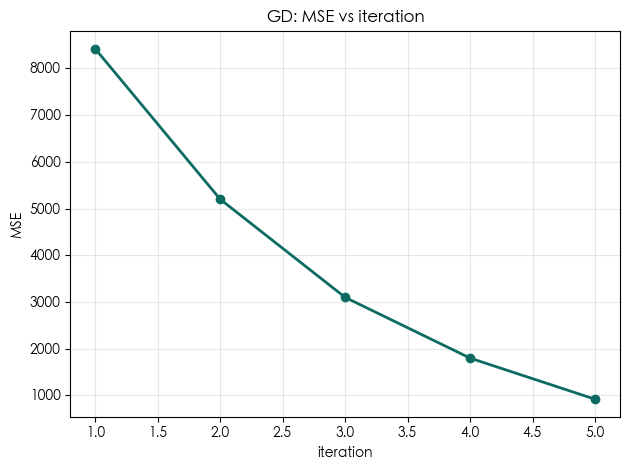

In [5]:
plot_gd_mse()

**思考** · MSE 从 8420 降到多少？

<details><summary>查看答案</summary>

约 920，单调下降。

</details>

## 2. 感知机边界

### 2.1 权重更新

错分样本推动法向量旋转，边界逐步分开两类。

**Perceptron**

```text
if misclassified: w += lr * y * x
```

In [6]:
perceptron_demo()

感知机边界 b 更新: -88 → -78 → -72 → -66


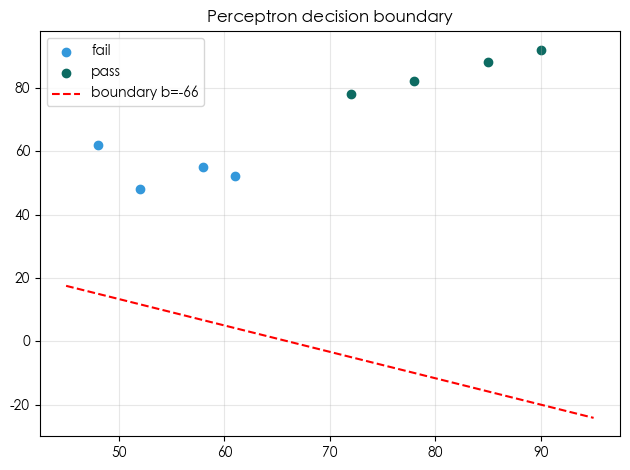

In [7]:
plot_perceptron()

**思考** · 边界 b 最终约多少？

<details><summary>查看答案</summary>

-66，见 plot 图例。

</details>

## 3. 阈值与 P/R

分类阈值 τ 影响 TP/FP/FN/TN；提高 τ 通常提高 P、降低 R。

In [8]:
display(metrics_table())

,阈值τ,TP,FP,FN,TN,P,R
0,0.35,42,28,8,22,0.60,0.84
1,0.50,38,12,12,38,0.76,0.76
2,0.65,30,4,20,46,0.88,0.60


**思考** · τ=0.65 时 P 与 R 如何？

<details><summary>查看答案</summary>

P 高 R 低，更保守。

</details>

## 4. 两层优化

内层 loss（MSE/hinge）驱动训练；外层 F1/P/R 评泛化，目标不一定同向。

## 小结

GD 逐步降 loss；感知机找线性可分边界；阈值调 P/R。

对照 [ch7.html](../ch7.html) 查看边界与 MSE 曲线。

## 练习

1. 学习率过大时 MSE 曲线会怎样？
2. 感知机对 XOR 数据能收敛吗？